<img src="https://raw.githubusercontent.com/drdave-teaching/OPIM5509-notebooks/main/_banners/opim5509_banner.svg" width="100%" alt="OPIM 5509 banner"/>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/drdave-teaching/OPIM5509-notebooks/blob/main/Module4/_energy_track/E2_Multivariate_Demand_RNN.ipynb)

# Multivariate RNN: Electricity Demand
--------------------------------------------------
**Dr. Dave Wanik - University of Connecticut**

Drop the lag columns. Hand the RNN the raw multivariate sequence as a **3-D tensor** `(samples, look-back, features)` - weather and clock on the left, **demand as the last column** - and let it decide what to remember. SimpleRNN first, then the one-word LSTM swap, then a stacked model with `return_sequences=True`, always scored against the naive baselines. A classification head (peak hour or not?) closes the notebook so you see both output types on one dataset.

*Energy-track version of the occupancy RNN notebook.*

🔴
<!-- 🎙 DAVE TALKING POINTS — M4 · 9B — Multivariate RNN Pt 1: split_sequences, column order, the 3-D tensor
- Multivariate differs from univariate only in prep: covariates on the left, target as the LAST column - and the target's own history stays in X. split_sequences takes y from the right.
- Look-back 24 -> (8736, 24, 8) train tensor. Walk the shape: samples, look-back, features. Inherit n_steps/n_features from the shape.
- SimpleRNN(30) with a LINEAR head (regression, MW) - params (8+30)*30+30 = 1,170 plus 31 for the head.
- Scale on train only; a separate scaler for the target so you can inverse_transform back to megawatts.
- Read the MAE against persistence (129) and seasonal naive (227): SimpleRNN ~48 MW, because the target's own past is in the window. That's the whole point of the column-order slide.
-->


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, classification_report, confusion_matrix
from keras.models import Sequential, load_model
from keras.layers import Input, Dense, Dropout, SimpleRNN, LSTM, GRU, Bidirectional, Conv1D, MaxPooling1D, Flatten
from keras.callbacks import EarlyStopping
import keras
keras.utils.set_random_seed(5509)   # reproducibility: same numbers every run (CPU exact; a GPU may drift a little)

## Read, sort, split

In [2]:
url = "https://raw.githubusercontent.com/drdave-teaching/OPIM5509Files/main/OPIM5509_Module4_Files/data/BDL_cleanweather_energy.csv"
df = pd.read_csv(url, parse_dates=["Datetime"])
print("in date order as delivered?", df["Datetime"].is_monotonic_increasing)      # it is NOT - always check
df = df.sort_values("Datetime").set_index("Datetime").ffill()

# two years is plenty for the lecture: train on 2018, test on 2019 - chronological, never shuffled
data  = df.loc["2018-01-01":"2019-12-31", ["BDL_tmpf", "BDL_dwpf", "BDL_relh", "Demand"]].copy()
data["hour_sin"] = np.sin(2*np.pi*data.index.hour/24); data["hour_cos"] = np.cos(2*np.pi*data.index.hour/24)
data["dow_sin"]  = np.sin(2*np.pi*data.index.dayofweek/7); data["dow_cos"] = np.cos(2*np.pi*data.index.dayofweek/7)
data = data[["BDL_tmpf", "BDL_dwpf", "BDL_relh", "hour_sin", "hour_cos", "dow_sin", "dow_cos", "Demand"]]   # Demand LAST
train, test = data.loc[:"2018-12-31"], data.loc["2019-01-01":]
print("train:", train.shape, "| test:", test.shape)
data.head()

in date order as delivered? False
train: (8760, 8) | test: (8760, 8)


,BDL_tmpf,BDL_dwpf,BDL_relh,hour_sin,hour_cos,dow_sin,dow_cos,Demand
Datetime,,,,,,,,
2018-01-01 00:00:00,1.9,0.0,56.85,0.000000,1.000000,0.0,1.0,3867.09
2018-01-01 01:00:00,0.0,0.0,62.12,0.258819,0.965926,0.0,1.0,3749.96
2018-01-01 02:00:00,0.0,0.0,61.38,0.500000,0.866025,0.0,1.0,3673.50
2018-01-01 03:00:00,0.0,0.0,71.11,0.707107,0.707107,0.0,1.0,3646.25
2018-01-01 04:00:00,0.0,0.0,64.21,0.866025,0.500000,0.0,1.0,3660.86


## Baselines

In [3]:
y = test["Demand"]
baselines = pd.Series({
    "mean-only":                       mean_absolute_error(y, np.full(len(y), train["Demand"].mean())),
    "seasonal naive (same hour yday)": mean_absolute_error(y.iloc[24:], y.shift(24).iloc[24:]),
    "persistence (last hour)":         mean_absolute_error(y.iloc[1:],  y.shift(1).iloc[1:]),
}, name="test MAE (MW)").round(1)
baselines

mean-only                          563.3
seasonal naive (same hour yday)    227.1
persistence (last hour)            129.0
Name: test MAE (MW), dtype: float64

## Prep: `split_sequences` and the 3-D tensor

Scale on train only. `split_sequences` takes the inputs from **every** column - demand's own past included - and the target from the last column at the **next** step.

<!-- WINDOW-FN -->
## The window-making function: `split_sequences`

Target in the **last column**, then:

- **`n_steps`** is the **look-back**: X is the last `n_steps` rows of **every column, the target included**. Yesterday's demand is the most useful input there is.
- y is the target **one step** after the window ends.

Result: X is `(samples, n_steps, n_features)`.


In [4]:
def split_sequences(seqs, n_steps):
    X, y = [], []
    for i in range(len(seqs) - n_steps):
        X.append(seqs[i:i+n_steps, :]); y.append(seqs[i+n_steps, -1])   # inputs = EVERY column (demand's own past included); target = last col, NEXT step
    return np.array(X), np.array(y)

n_steps = 24
sc   = MinMaxScaler().fit(train)               # fit on TRAIN only
sc_y = MinMaxScaler().fit(train[["Demand"]])   # a separate scaler for the target so we can get MW back
tr_s, te_s = sc.transform(train), sc.transform(test)
X_train, y_train = split_sequences(tr_s, n_steps)
X_test,  y_test  = split_sequences(te_s, n_steps)
n_features = X_train.shape[2]
y_true = sc_y.inverse_transform(y_test.reshape(-1, 1)).ravel()   # test target in MW
print("train tensor:", X_train.shape, "-> (samples, look-back, features) | test:", X_test.shape)

train tensor: (8736, 24, 8) -> (samples, look-back, features) | test: (8736, 24, 8)


## SimpleRNN with a linear head

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 30)             │         1,170 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,201 (4.69 KB)

 Trainable params: 1,201 (4.69 KB)

 Non-trainable params: 0 (0.00 B)

...

104/110 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.7193e-04 - mae: 0.0100

110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.7261e-04 - mae: 0.0101

110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.7261e-04 - mae: 0.0101 - val_loss: 1.9822e-04 - val_mae: 0.0108


Epoch 50: early stopping


Restoring model weights from the end of the best epoch: 42.


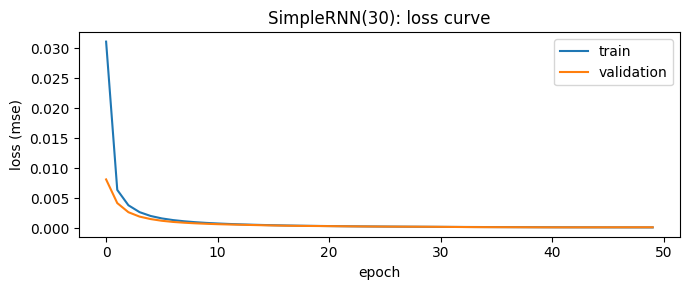

stopped after 50 epochs; best validation loss 0.00019


In [5]:
es = EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True, verbose=1)

rnn = Sequential()
rnn.add(Input(shape=(n_steps, n_features)))
rnn.add(SimpleRNN(30))
rnn.add(Dense(1))   # linear output: we predict megawatts
rnn.compile(optimizer="adam", loss="mse", metrics=["mae"])
rnn.summary()
hist = hist = rnn.fit(X_train, y_train, epochs=50, batch_size=64, validation_split=0.2, callbacks=[es], verbose=1)

# the loss curve - always keep the History object that fit() hands back
plt.figure(figsize=(7, 3))
plt.plot(hist.history["loss"], label="train")
if "val_loss" in hist.history:
    plt.plot(hist.history["val_loss"], label="validation")
plt.xlabel("epoch"); plt.ylabel("loss (mse)"); plt.title("SimpleRNN(30): loss curve")
plt.legend(); plt.tight_layout(); plt.show()
print(f"stopped after {len(hist.history['loss'])} epochs;"
      f" best validation loss {min(hist.history['val_loss']):.5f}")

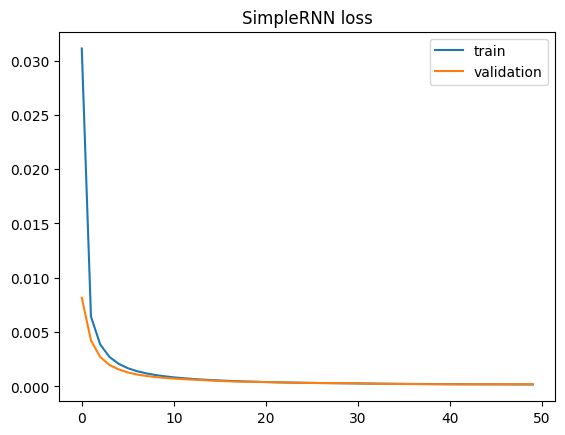

SimpleRNN test MAE: 47.9 MW   (persistence: 129.0, seasonal naive: 227.1)


In [6]:
plt.plot(hist.history["loss"], label="train"); plt.plot(hist.history["val_loss"], label="validation"); plt.legend(); plt.title("SimpleRNN loss"); plt.show()
pred_rnn = sc_y.inverse_transform(rnn.predict(X_test, verbose=0)).ravel()
mae_rnn = mean_absolute_error(y_true, pred_rnn)
print(f"SimpleRNN test MAE: {mae_rnn:.1f} MW   (persistence: {baselines.iloc[2]:.1f}, seasonal naive: {baselines.iloc[1]:.1f})")

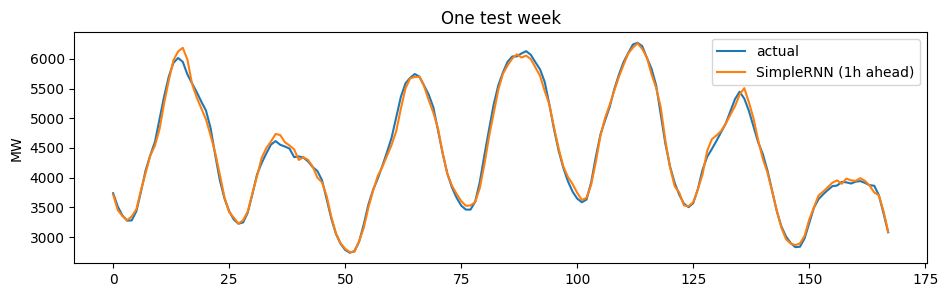

In [7]:
i0 = 24*7*28
plt.figure(figsize=(11, 3)); plt.plot(y_true[i0:i0+24*7], label="actual"); plt.plot(pred_rnn[i0:i0+24*7], label="SimpleRNN (1h ahead)")
plt.title("One test week"); plt.ylabel("MW"); plt.legend(); plt.show()

🔴
<!-- 🎙 DAVE TALKING POINTS — M4 · 10B — Multivariate RNN Pt 2: the LSTM swap, stacking, and a classification head
- One-word swap: SimpleRNN -> LSTM. Params x4: (8+30)*30+30 = 1,170 -> 4,680. Read it off summary().
- Stacked: return_sequences=True keeps the (24, 30) sequence for the second layer. More capacity is not automatically better - read the table.
- Bake-off table: persistence 129, seasonal naive 227, SimpleRNN ~48, LSTM ~43, stacked ~67 (worse - more capacity is not automatically better). The number to say: how much value over the naive baseline.
- Classification head on the SAME tensors: is this a peak hour (top 10% of training demand)? sigmoid + binary_crossentropy; majority baseline 90% so read precision/recall.
- Save -> load_model -> identical predictions. Reproducibility is a seed AND a saved artifact.
-->


## The LSTM swap, and a stacked RNN

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30)             │         4,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,711 (18.40 KB)

 Trainable params: 4,711 (18.40 KB)

 Non-trainable params: 0 (0.00 B)

Restoring model weights from the end of the best epoch: 50.


LSTM test MAE: 43.2 MW   (persistence: 129.0, seasonal naive: 227.1)


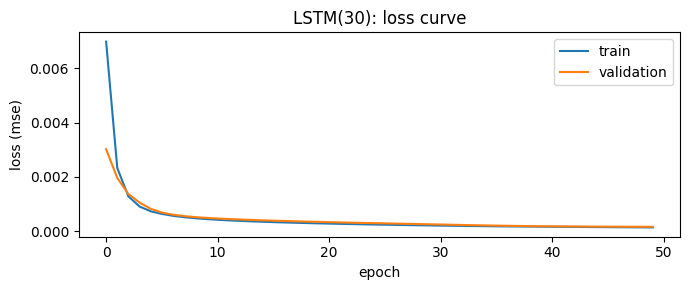

stopped after 50 epochs; best validation loss 0.00016


In [8]:
lstm = Sequential()
lstm.add(Input(shape=(n_steps, n_features)))
lstm.add(LSTM(30))
lstm.add(Dense(1))
lstm.compile(optimizer="adam", loss="mse", metrics=["mae"])
lstm.summary()
hist_lstm = lstm.fit(X_train, y_train, epochs=50, batch_size=64, validation_split=0.2, callbacks=[es], verbose=0)
pred_lstm = sc_y.inverse_transform(lstm.predict(X_test, verbose=0)).ravel()
mae_lstm = mean_absolute_error(y_true, pred_lstm)
print(f"LSTM test MAE: {mae_lstm:.1f} MW   (persistence: {baselines.iloc[2]:.1f}, seasonal naive: {baselines.iloc[1]:.1f})")

# the loss curve - always keep the History object that fit() hands back
plt.figure(figsize=(7, 3))
plt.plot(hist_lstm.history["loss"], label="train")
if "val_loss" in hist_lstm.history:
    plt.plot(hist_lstm.history["val_loss"], label="validation")
plt.xlabel("epoch"); plt.ylabel("loss (mse)"); plt.title("LSTM(30): loss curve")
plt.legend(); plt.tight_layout(); plt.show()
print(f"stopped after {len(hist_lstm.history['loss'])} epochs;"
      f" best validation loss {min(hist_lstm.history['val_loss']):.5f}")

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 24, 30)         │         1,170 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 30)             │         1,830 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,031 (11.84 KB)

 Trainable params: 3,031 (11.84 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 27: early stopping


Restoring model weights from the end of the best epoch: 19.


stacked SimpleRNN test MAE: 67.1 MW   (persistence: 129.0, seasonal naive: 227.1)


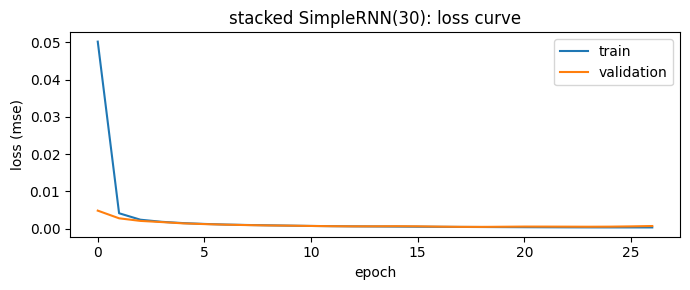

stopped after 27 epochs; best validation loss 0.00044


In [9]:
stacked = Sequential()
stacked.add(Input(shape=(n_steps, n_features)))
stacked.add(SimpleRNN(30, return_sequences=True))    # hands the whole (24, 30) sequence down
stacked.add(SimpleRNN(30))
stacked.add(Dense(1))
stacked.compile(optimizer="adam", loss="mse", metrics=["mae"])
stacked.summary()
hist_stacked = stacked.fit(X_train, y_train, epochs=50, batch_size=64, validation_split=0.2, callbacks=[es], verbose=0)
pred_stacked = sc_y.inverse_transform(stacked.predict(X_test, verbose=0)).ravel()
mae_stacked = mean_absolute_error(y_true, pred_stacked)
print(f"stacked SimpleRNN test MAE: {mae_stacked:.1f} MW   (persistence: {baselines.iloc[2]:.1f}, seasonal naive: {baselines.iloc[1]:.1f})")

# the loss curve - always keep the History object that fit() hands back
plt.figure(figsize=(7, 3))
plt.plot(hist_stacked.history["loss"], label="train")
if "val_loss" in hist_stacked.history:
    plt.plot(hist_stacked.history["val_loss"], label="validation")
plt.xlabel("epoch"); plt.ylabel("loss (mse)"); plt.title("stacked SimpleRNN(30): loss curve")
plt.legend(); plt.tight_layout(); plt.show()
print(f"stopped after {len(hist_stacked.history['loss'])} epochs;"
      f" best validation loss {min(hist_stacked.history['val_loss']):.5f}")

In [10]:
pd.Series({"mean-only": baselines.iloc[0], "seasonal naive": baselines.iloc[1], "persistence": baselines.iloc[2],
           "SimpleRNN": mae_rnn, "LSTM": mae_lstm, "stacked SimpleRNN": mae_stacked}, name="test MAE, 1h ahead (MW)").round(1)

mean-only            563.3
seasonal naive       227.1
persistence          129.0
SimpleRNN             47.9
LSTM                  43.2
stacked SimpleRNN     67.1
Name: test MAE, 1h ahead (MW), dtype: float64

## Same tensors, a classification head: is this a peak hour?

Define a peak as the **top 10% of training-set demand**. Change the head to `sigmoid`, the loss to `binary_crossentropy`, and read precision/recall - the majority-class baseline is 90%, so accuracy tells you nothing.

peak threshold: 4313 MW | peak share in test: 7.4%


Epoch 24: early stopping


Restoring model weights from the end of the best epoch: 16.


              precision    recall  f1-score   support

 normal hour       0.99      0.99      0.99      8089
   PEAK hour       0.89      0.83      0.86       647

    accuracy                           0.98      8736
   macro avg       0.94      0.91      0.92      8736
weighted avg       0.98      0.98      0.98      8736

[[8024   65]
 [ 110  537]]


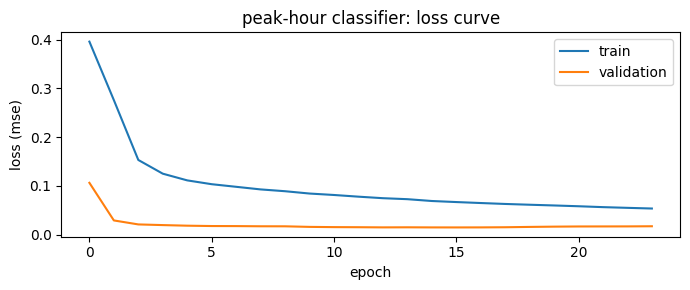

stopped after 24 epochs; best validation loss 0.01472


In [11]:
thr = train["Demand"].quantile(0.90)
peak_train = (sc_y.inverse_transform(y_train.reshape(-1, 1)).ravel() > thr).astype(int)
peak_test  = (y_true > thr).astype(int)
print(f"peak threshold: {thr:.0f} MW | peak share in test: {peak_test.mean():.1%}")

clf = Sequential()
clf.add(Input(shape=(n_steps, n_features)))
clf.add(LSTM(30))
clf.add(Dense(1, activation="sigmoid"))
clf.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
hist_clf = clf.fit(X_train, peak_train, epochs=50, batch_size=64, validation_split=0.2, callbacks=[es], verbose=0)
p = (clf.predict(X_test, verbose=0).ravel() > 0.5).astype(int)
print(classification_report(peak_test, p, target_names=["normal hour", "PEAK hour"]))
print(confusion_matrix(peak_test, p))

# the loss curve - always keep the History object that fit() hands back
plt.figure(figsize=(7, 3))
plt.plot(hist_clf.history["loss"], label="train")
if "val_loss" in hist_clf.history:
    plt.plot(hist_clf.history["val_loss"], label="validation")
plt.xlabel("epoch"); plt.ylabel("loss (mse)"); plt.title("peak-hour classifier: loss curve")
plt.legend(); plt.tight_layout(); plt.show()
print(f"stopped after {len(hist_clf.history['loss'])} epochs;"
      f" best validation loss {min(hist_clf.history['val_loss']):.5f}")

### Where those three averages actually come from

`classification_report` prints macro and weighted averages without showing its work, which makes them easy to
mix up. The table below does every intermediate step, so you can follow a single number from the confusion matrix
all the way to the summary line.

- **precision** = of the hours it called a peak, how many were - $TP/(TP+FP)$
- **recall** = of the real peaks, how many it caught - $TP/(TP+FN)$
- $F_1$ = their harmonic mean
- **support** $n_c$ = how many test hours really belong to that class

Then the only difference between the two averages is the weight:

$$\text{macro } F_1 = \frac{1}{C}\sum_c F_1^{(c)} \qquad\qquad
\text{weighted } F_1 = \frac{\sum_c n_c F_1^{(c)}}{\sum_c n_c}$$

Peaks are 10% of the data, so **weighted** is dominated by the normal hours and **macro** is not. Watch what that
does to the majority-class baseline at the bottom.

In [12]:
def metrics_table(y_true_cls, y_pred_cls, labels=("normal hour", "PEAK hour")):
    """Every intermediate number behind accuracy / macro F1 / weighted F1, shown rather than asserted."""
    rows = []
    for k, name in enumerate(labels):
        tp = int(((y_pred_cls == k) & (y_true_cls == k)).sum())
        fp = int(((y_pred_cls == k) & (y_true_cls != k)).sum())
        fn = int(((y_pred_cls != k) & (y_true_cls == k)).sum())
        prec = tp / (tp + fp) if tp + fp else 0.0
        rec  = tp / (tp + fn) if tp + fn else 0.0
        f1   = 2 * prec * rec / (prec + rec) if prec + rec else 0.0
        n_c  = int((y_true_cls == k).sum())
        rows.append({"class": name, "TP": tp, "FP": fp, "FN": fn,
                     "precision": prec, "recall": rec, "F1": f1,
                     "support n_c": n_c, "n_c x F1": n_c * f1})
    t = pd.DataFrame(rows).set_index("class")
    N        = int(t["support n_c"].sum())
    correct  = int((y_pred_cls == y_true_cls).sum())
    macro    = t["F1"].mean()
    weighted = t["n_c x F1"].sum() / N
    display(t.round(4))
    print(f"accuracy    = correct / all      = {correct:,} / {N:,} = {correct/N:.4f}")
    print(f"macro F1    = (F1_0 + F1_1) / 2  = ({t['F1'].iloc[0]:.4f} + {t['F1'].iloc[1]:.4f}) / 2 = {macro:.4f}")
    print(f"weighted F1 = sum(n_c x F1) / N  = {t['n_c x F1'].sum():,.1f} / {N:,} = {weighted:.4f}")
    return t

print("=== the LSTM classification head ===")
_ = metrics_table(peak_test, p)

print("\n=== the majority-class baseline: never call a peak ===")
_ = metrics_table(peak_test, np.zeros_like(peak_test))
print("\nAccuracy barely moves. Macro F1 falls off a cliff - that is the number that catches a useless model.")

=== the LSTM classification head ===


,TP,FP,FN,precision,recall,F1,support n_c,n_c x F1
class,,,,,,,,
normal hour,8024,110,65,0.9865,0.992,0.9892,8089,8001.7427
PEAK hour,537,65,110,0.8920,0.830,0.8599,647,556.3475


accuracy    = correct / all      = 8,561 / 8,736 = 0.9800
macro F1    = (F1_0 + F1_1) / 2  = (0.9892 + 0.8599) / 2 = 0.9246
weighted F1 = sum(n_c x F1) / N  = 8,558.1 / 8,736 = 0.9796

=== the majority-class baseline: never call a peak ===


,TP,FP,FN,precision,recall,F1,support n_c,n_c x F1
class,,,,,,,,
normal hour,8089,647,0,0.9259,1.0,0.9615,8089,7777.9401
PEAK hour,0,0,647,0.0000,0.0,0.0000,647,0.0000


accuracy    = correct / all      = 8,089 / 8,736 = 0.9259
macro F1    = (F1_0 + F1_1) / 2  = (0.9615 + 0.0000) / 2 = 0.4808
weighted F1 = sum(n_c x F1) / N  = 7,777.9 / 8,736 = 0.8903

Accuracy barely moves. Macro F1 falls off a cliff - that is the number that catches a useless model.


## Save the model and use it again

In [13]:
lstm.save('E2_Multivariate_Demand_RNN.keras')
reloaded = load_model('E2_Multivariate_Demand_RNN.keras')
print("reloaded model reproduces the predictions:", np.allclose(lstm.predict(X_test[:5], verbose=0), reloaded.predict(X_test[:5], verbose=0)))

reloaded model reproduces the predictions: True


## On your own

- Change `n_steps` to 6, then 168. Which look-back wins for one hour ahead? For the peak-hour flag?
- Add `Dropout(0.2)` after the recurrent layer. Does it help a model that is already close to persistence?
- Swap `LSTM` for `GRU` - count the parameters before you run it (G=3).